In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Ostfalia Hochschule für Angewandte Wissenschaften' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/01bk10867' -- 'Ostfalia Hochschule für Angewandte Wissenschaften'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Health Science, Ostfalia University...",https://openalex.org/W4404641535
1,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Fakultät Gesundheitswesen, Ostfalia Hochschule...",https://openalex.org/W4399877944
2,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Campu...",https://openalex.org/W4399877944
3,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Campu...",https://openalex.org/W4399877944
4,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute for Information Engineering, Ostfali...",https://openalex.org/W4285804440


In [214]:
MAPPING_DICT = {
    'Fakultät Bau-Wasser-Boden': ['bau-wasser-boden', 'civil engineering', 'enviro(n)?mental engineering', 'civil department'],
    'Fakultät Handel und Soziale Arbeit': ['trade and social work'],
    'Fakultät Verkehr-Sport-Tourismus-Medien': ['media management', 'tourism-media', 'public communication', 'regionalforschung'],
    'Fakultät Elektro- und Informationstechnik': ['electrical (engineering|energy|systems)'],
    'Fakultät Informatik': ['information engineering', 'informatik', 'computer science', 'robotics lab', 'distributed systems', 'faculty for( applied)? informatics'],
    'Fakultät Maschinenbau': ['mechatroni(k|cs)', 'mechanical engineering', 'production technolog(y|ies)', 'maschinenbau'],
    'Fakultät Recht': ['economic law', '(bels)'],
    'Fakultät Soziale Arbeit': ['soziale(n)? arbeit', 'social work'],
    'Fakultät Versorgungstechnik': ['biotechnology', 'kommunikationssysteme', 'supply (engineering|technology)'],
    'Fakultät Fahrzeugtechnik': ['recycling', 'vehicle', 'automotive engineering', 'fahrzeugbau'],
    'Fakultät Gesundheitswesen': ['health(\s)?(care|science|service)', 'gesundheit'],
    'Fakultät Wirtschaft': ['fakultät wirtschaft', 'faculty of business', 'business administration']
}

In [215]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [216]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [217]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Gesundheitswesen,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Health Science, Ostfalia University...",https://openalex.org/W4404641535
1,Fakultät Gesundheitswesen,Ostfalia Hochschule für Angewandte Wissenschaften,"Fakultät Gesundheitswesen, Ostfalia Hochschule...",https://openalex.org/W4399877944
2,Fakultät Gesundheitswesen,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Campu...",https://openalex.org/W4399877944
3,Fakultät Gesundheitswesen,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Campu...",https://openalex.org/W4399877944
4,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute for Information Engineering, Ostfali...",https://openalex.org/W4285804440
...,...,...,...,...
769,None,Ostfalia Hochschule für Angewandte Wissenschaften,"Redaktionskomitee, Prof. Dr., GNP, ...",https://openalex.org/W3082053184
770,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Forschungsgruppe Biostatistik, Helmholtz Zentr...",https://openalex.org/W3094297015
771,Fakultät Maschinenbau,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Mechanical Engineering, Ostfalia Un...",https://openalex.org/W3014187372
772,None,Ostfalia Hochschule für Angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaf...,https://openalex.org/W3094548699


In [218]:
df_with_inst[(df_with_inst.inst_name.isnull()) & df_with_inst.raw_affiliation_string.str.contains('ostfalia', case=False, regex=False)].raw_affiliation_string.unique()

array(['Ostfalia Hochschule für angewandte Wissenschaften, Rothenfelder Straße 10, 38440, Wolfsburg, Deutschland',
       'Ostfalia Hochschule für angewandte Wissenschaften, Rothenfelder Straße 10, 38440 Wolfsburg, Deutschland',
       'Ostfalia Hochschule, Wolfsburg, Deutschland',
       'Ostfalia Hochschule für angewandte Wissenschaften - Hochschule Braunschweig/Wolfenbüttel, Wolfsburg, Deutschland',
       'Ostfalia Hochschule für angewandte Wissenschaften, Wolfsburg, Deutschland',
       'Ostfalia University of Applied Sciences, Wolfenbüttel, Germany',
       'Ostfalia University of Applied Science',
       'Ostfalia University of Applied Sciences',
       'Ostfalia University of applied sciences, Salzdahlumer Straße 46/48, 38302 Wolfenbüttel, Germany',
       'Ostfalia Hochschule für angewandte Wissenschaften (Germany)',
       'Ostfalia -Hochschule Braun-schweig/Wolfenbüttel.',
       'Ostfalia University of Applied Sciences, Salzdahlumer Str. 46/48, 38302 Wolfenbuettel, Germany,

In [219]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Fakultät Bau-Wasser-Boden,10
1,Fakultät Elektro- und Informationstechnik,53
2,Fakultät Fahrzeugtechnik,12
3,Fakultät Gesundheitswesen,66
4,Fakultät Handel und Soziale Arbeit,6
5,Fakultät Informatik,169
6,Fakultät Maschinenbau,93
7,Fakultät Recht,15
8,Fakultät Soziale Arbeit,31
9,Fakultät Verkehr-Sport-Tourismus-Medien,13


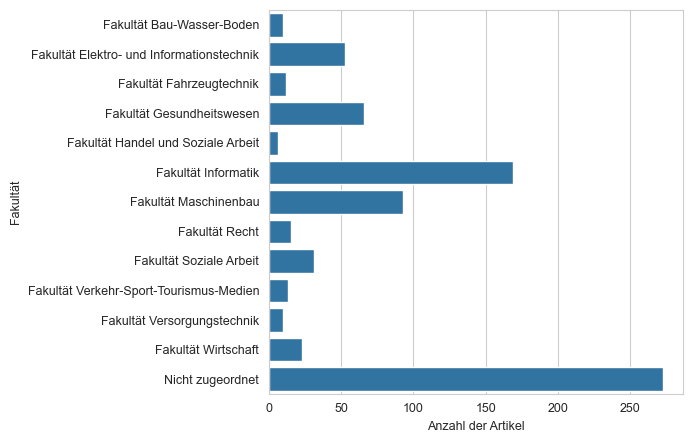

In [220]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [221]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6472868217054264